# Credit Card Default Risk — Exploratory Data Analysis

## Objective

Explore the UCI Default of Credit Card Clients dataset to understand its structure, features, target variable, data quality, and class distribution before preprocessing and model training.

In [1]:
import pandas as pd

In [2]:
file_path = "../data/raw/default of credit card clients.xls"

In [3]:
preview = pd.read_excel(file_path, header=None)

preview.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,NaN,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
3,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
4,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [4]:
df = pd.read_excel(file_path, header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.shape

(30000, 25)

In [6]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [8]:
df["SEX"].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

In [9]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [10]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [11]:
df["PAY_0"].value_counts().sort_index()

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [12]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df[pay_cols].describe()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100
std,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [13]:
numeric_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1"]

df[numeric_cols].describe()

,LIMIT_BAL,AGE,BILL_AMT1
count,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900
std,129747.661567,9.217904,73635.860576
min,10000.000000,21.000000,-165580.000000
25%,50000.000000,28.000000,3558.750000
50%,140000.000000,34.000000,22381.500000
75%,240000.000000,41.000000,67091.000000
max,1000000.000000,79.000000,964511.000000


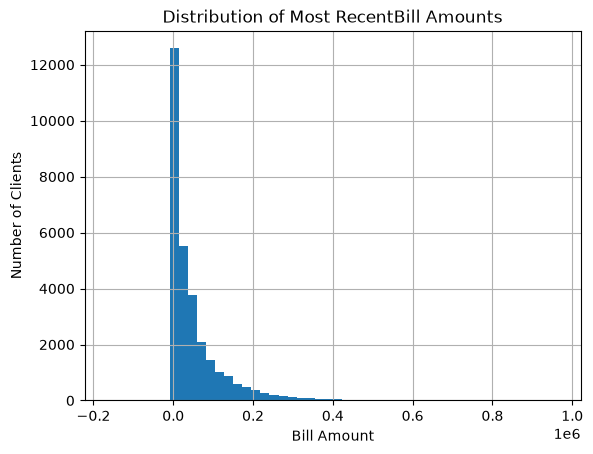

In [14]:
import matplotlib.pyplot as plt 

df["BILL_AMT1"].hist(bins=50)

plt.xlabel("Bill Amount")
plt.ylabel("Number of Clients")
plt.title("Distribution of Most RecentBill Amounts")
plt.show()

In [15]:
df["default payment next month"].value_counts().sort_index()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [16]:
df["default payment next month"].value_counts(normalize=True) * 100

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop(columns="ID").duplicated().sum()

np.int64(35)

In [19]:
df["ID"].nunique()

30000

## EDA Findings

- The dataset contains 30,000 client records and 25 columns.
- Each client has a unique ID. The ID is an identifier and will not be used as a predictive feature.
- No standard missing values were detected.
- No complete duplicate rows were found.
- When ID is excluded, 35 rows duplicate an earlier feature/target profile. These records will be retained for now because there is not enough evidence to classify them as erroneous duplicates.
- EDUCATION contains undocumented category codes 0, 5, and 6.
- MARRIAGE contains undocumented category code 0.
- Repayment-status variables contain special negative codes that require careful interpretation.
- BILL_AMT1 is strongly right-skewed and contains some negative values.
- The target is imbalanced:
  - No default (0): 77.88%
  - Default (1): 22.12%
- A majority-class baseline would achieve 77.88% accuracy while detecting no defaults, so accuracy alone will not be sufficient for evaluating our models.

## Preprocessing

Separate the dataset into predictive features (X) and the target variable (y). The ID column is excluded because it is an identifier rather than a meaningful predictive feature.

In [25]:
X = df.drop(columns=["ID", "default payment next month"])
y = df["default payment next month"]

X.shape, y.shape

((30000, 23), (30000,))

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [27]:
X_train.shape, X_temp.shape

((21000, 23), (9000, 23))

In [28]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [29]:
X_train.shape, X_val.shape, X_test.shape

((21000, 23), (4500, 23), (4500, 23))

In [30]:
print("Training:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Training:
default payment next month
0    77.880952
1    22.119048
Name: proportion, dtype: float64

Validation:
default payment next month
0    77.888889
1    22.111111
Name: proportion, dtype: float64

Test:
default payment next month
0    77.866667
1    22.133333
Name: proportion, dtype: float64


In [31]:
for dataset in [X_train, X_val, X_test]:
    dataset["EDUCATION"] = dataset["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    dataset["MARRIAGE"] = dataset["MARRIAGE"].replace({0: 3})

In [32]:
print(X_train["EDUCATION"].value_counts().sort_index())
print()
print(X_train["MARRIAGE"].value_counts().sort_index())

EDUCATION
1    7379
2    9833
3    3440
4     348
Name: count, dtype: int64

MARRIAGE
1     9526
2    11208
3      266
Name: count, dtype: int64


In [33]:
print("Validation EDUCATION:", sorted(X_val["EDUCATION"].unique()))
print("Test EDUCATION:", sorted(X_test["EDUCATION"].unique()))

print("Validation MARRIAGE:", sorted(X_val["MARRIAGE"].unique()))
print("Test MARRIAGE:", sorted(X_test["MARRIAGE"].unique()))

Validation EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Validation MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]
Test MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


In [34]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

repayment_features = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

In [35]:
numerical_features = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

In [36]:
len(categorical_features) + len(repayment_features) + len(numerical_features)

23

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
        ("repay", "passthrough", repayment_features)
    ]
)

In [39]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [40]:
X_train.shape, X_train_processed.shape

((21000, 23), (21000, 26))

In [41]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['cat__SEX_2', 'cat__EDUCATION_2', 'cat__EDUCATION_3',
       'cat__EDUCATION_4', 'cat__MARRIAGE_2', 'cat__MARRIAGE_3',
       'num__LIMIT_BAL', 'num__AGE', 'num__BILL_AMT1', 'num__BILL_AMT2',
       'num__BILL_AMT3', 'num__BILL_AMT4', 'num__BILL_AMT5',
       'num__BILL_AMT6', 'num__PAY_AMT1', 'num__PAY_AMT2',
       'num__PAY_AMT3', 'num__PAY_AMT4', 'num__PAY_AMT5', 'num__PAY_AMT6',
       'repay__PAY_0', 'repay__PAY_2', 'repay__PAY_3', 'repay__PAY_4',
       'repay__PAY_5', 'repay__PAY_6'], dtype=object)

In [42]:
import numpy as np

In [43]:
baseline_predictions = np.zeros(len(y_val), dtype=int)

from sklearn.metrics import accuracy_score, precision_score, recall_score

baseline_accuracy = accuracy_score(y_val, baseline_predictions)
baseline_precision = precision_score(y_val, baseline_predictions, zero_division=0)
baseline_recall = recall_score(y_val, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)

Baseline Accuracy: 0.7788888888888889
Baseline Precision: 0.0
Baseline Recall: 0.0
